In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader
from timm import create_model
from tensorflow.keras.preprocessing.image import load_img
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from google.colab import drive

In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Define paths to dataset
dataset_path = "/content/drive/MyDrive/dataset/Stroke_classification"
train_dir = os.path.join(dataset_path, "Train")
test_dir = os.path.join(dataset_path, "Test")
classes = ["Normal", "Haemorrhagic"]

In [4]:
# Display sample images
def display_sample_images(dataset_path):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    for i, category in enumerate(classes):
        category_path = os.path.join(dataset_path, category)
        img_name = os.listdir(category_path)[1]  # Take random image
        img = load_img(os.path.join(category_path, img_name), target_size=(224, 224))
        axes[i].imshow(img)
        axes[i].set_title(category)
        axes[i].axis("off")
    plt.show()

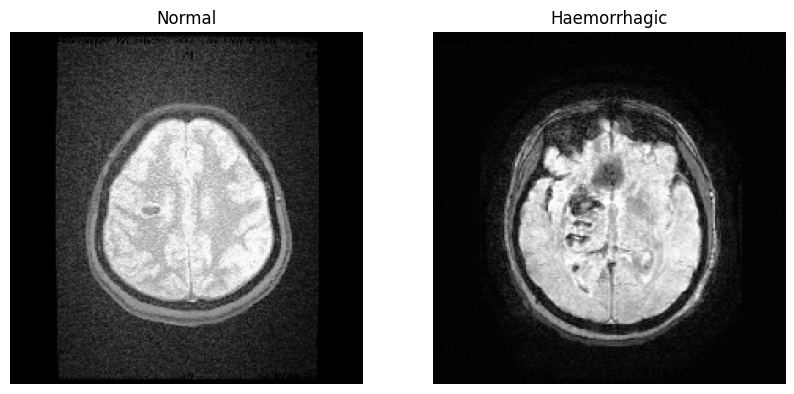

In [5]:
display_sample_images(train_dir)

In [6]:
# Data Preprocessing
image_size = (224, 224)
batch_size = 32

In [7]:
# Define preprocessing with padding to maintain aspect ratio
def preprocess_image():
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # Resize with interpolation
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    return transform

In [8]:
transform = preprocess_image()
train_dir = os.path.join(dataset_path, "Train")
test_dir = os.path.join(dataset_path, "Test")
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [9]:
# Load Vision Transformer model
num_classes = len(train_dataset.classes)
model = create_model("vit_small_patch16_224", pretrained=True, num_classes=num_classes) # vit_small_patch16_224

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [10]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

In [11]:
def train_model(model, train_loader, criterion, optimizer, num_epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.train()

    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")


In [12]:
train_model(model, train_loader, criterion, optimizer, num_epochs=20)

Epoch 1, Loss: 1.1444
Epoch 2, Loss: 0.4037
Epoch 3, Loss: 0.1170
Epoch 4, Loss: 0.0905
Epoch 5, Loss: 0.0733
Epoch 6, Loss: 0.1382
Epoch 7, Loss: 0.0395
Epoch 8, Loss: 0.0137
Epoch 9, Loss: 0.0014
Epoch 10, Loss: 0.0011
Epoch 11, Loss: 0.0016
Epoch 12, Loss: 0.0003
Epoch 13, Loss: 0.0000
Epoch 14, Loss: 0.0000
Epoch 15, Loss: 0.0000
Epoch 16, Loss: 0.0000
Epoch 17, Loss: 0.0000
Epoch 18, Loss: 0.0000
Epoch 19, Loss: 0.0000
Epoch 20, Loss: 0.0000


In [13]:
def evaluate_model(model, test_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    conf_matrix = confusion_matrix(all_labels, all_preds)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:")
    print(conf_matrix)

In [14]:
evaluate_model(model, test_loader)

Accuracy: 0.8600
Precision: 0.8750
Recall: 0.8600
F1 Score: 0.8586
Confusion Matrix:
[[38 12]
 [ 2 48]]


In [15]:
# Function to predict a new image
def predict_image(image_path, model):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    transform = preprocess_image()
    img = Image.open(image_path)
    img = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img)
        _, predicted_class = torch.max(output, 1)

    predicted_label = classes[predicted_class.item()]
    img = Image.open(image_path)
    plt.imshow(img)
    plt.title(f"Predicted Class: {predicted_label}")
    plt.axis("off")
    plt.show()

    return predicted_label

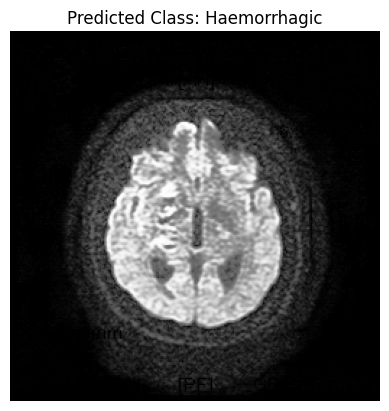

'Haemorrhagic'

In [20]:
predict_image("/content/drive/MyDrive/dataset/Stroke_classification/Test/Haemorrhagic/Manjula DWI-15.jpg_Haemorrhagic_108.png", model)

In [21]:
torch.save(model.state_dict(), "vit_model_weights.pth")  # Save only weights